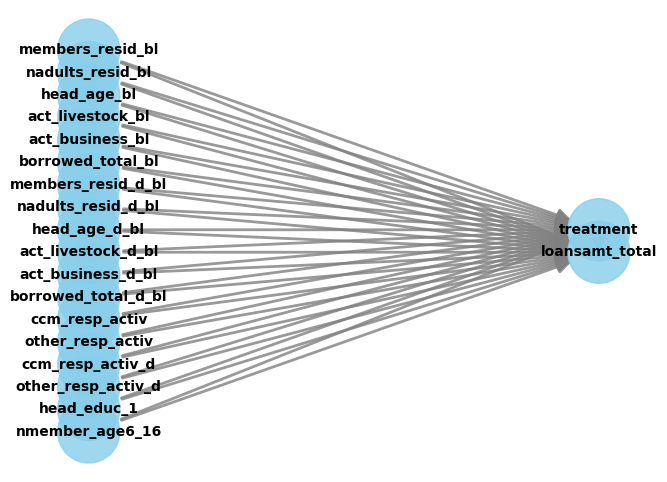

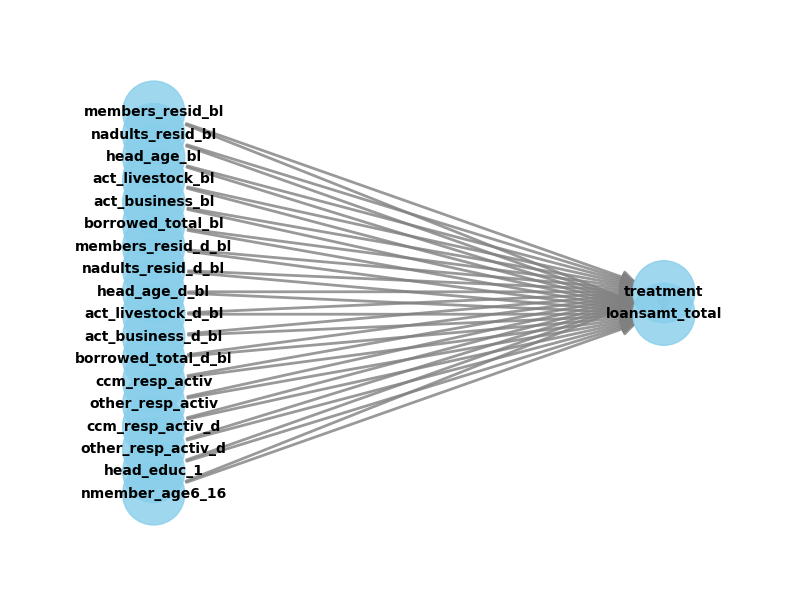

In [23]:
import pandas as pd
from dowhy import CausalModel
from IPython.display import Image, display

# read Stata .dta file 
df = pd.read_stata("data_rep.dta")

# set variables 
treatment = 'treatment'
outcome = 'loansamt_total'
covariates = ["members_resid_bl", "nadults_resid_bl", "head_age_bl", "act_livestock_bl", "act_business_bl",
              "borrowed_total_bl", "members_resid_d_bl", "nadults_resid_d_bl", "head_age_d_bl",
              "act_livestock_d_bl", "act_business_d_bl", "borrowed_total_d_bl", "ccm_resp_activ",
              "other_resp_activ", "ccm_resp_activ_d", "other_resp_activ_d", "head_educ_1", "nmember_age6_16"]

# build causal graph with dowhy 
model = CausalModel(
    data=df,
    treatment=treatment, 
    outcome=outcome, 
    common_causes=covariates, 
    instruments=None, 
    effect_modifiers=None)
model.view_model()
display(Image(filename="causal_model.png"))

In [24]:
# drop missing data 
from sklearn.model_selection import train_test_split


all_variables = covariates+[treatment]+[outcome]
df = df.dropna(axis=0, subset=all_variables)

# split data into train and test sets 
train, test = train_test_split(df, test_size=0.2)

# set variables for causal forest Y=outcome, T=treatment, X=covariates, W=effect_modifiers 
Y = train[outcome]
T = train[treatment]
X = train[covariates]
W = None
X_test = test[covariates]

In [26]:
len(covariates)

In [25]:
df

,ident,id1,id2,id3,id4,id10_d,id11_d,id13,m1,m2,...,sampleall,samplemodel,noweight,attrition,lostobs,meattrition,attrition_treat,meattrition_treat,ccm_resp_activ_d,other_resp_activ_d
0,169082,18,52,169,82,NaN,NaN,1.0,5.0,3,...,1.0,1.0,1.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0
1,172060,18,52,172,60,NaN,NaN,1.0,7.0,5,...,1.0,1.0,1.0,NaN,0.0,0.0,NaN,0.0,1.0,1.0
2,172005,18,52,172,5,NaN,NaN,1.0,3.0,3,...,1.0,1.0,1.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0
3,170065,18,52,170,65,NaN,NaN,1.0,10.0,4,...,1.0,1.0,1.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0
4,170021,18,52,170,21,NaN,NaN,1.0,5.0,2,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5519,097012,14,26,97,12,1909.0,NaN,1.0,9.0,5,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5520,097038,14,26,97,38,2103.0,NaN,1.0,12.0,7,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5521,097040,14,26,97,40,2003.0,NaN,1.0,9.0,6,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5522,097029,14,26,97,29,1903.0,NaN,1.0,5.0,4,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
from econml.dml import CausalForestDML
from sklearn.linear_model import MultiTaskLassoCV, LassoCV

# set parameters for causal forest 
causal_forest = CausalForestDML(criterion='het', 
                                n_estimators=10000,       
                                min_samples_leaf=10, 
                                max_depth=None, 
                                max_samples=0.5,
                                discrete_treatment=False,
                                honest=True,
                                inference=True,
                                cv=10,
                                model_t=LassoCV(), 
                                model_y=LassoCV(),
                                )
                      
# fit train data to causal forest model 
causal_forest.fit(Y, T, X=X, W=W)
# estimate the CATE with the test set 
causal_forest.const_marginal_ate(X_test)

 97%|=================== | 4280/4406 [00:31<00:00]       

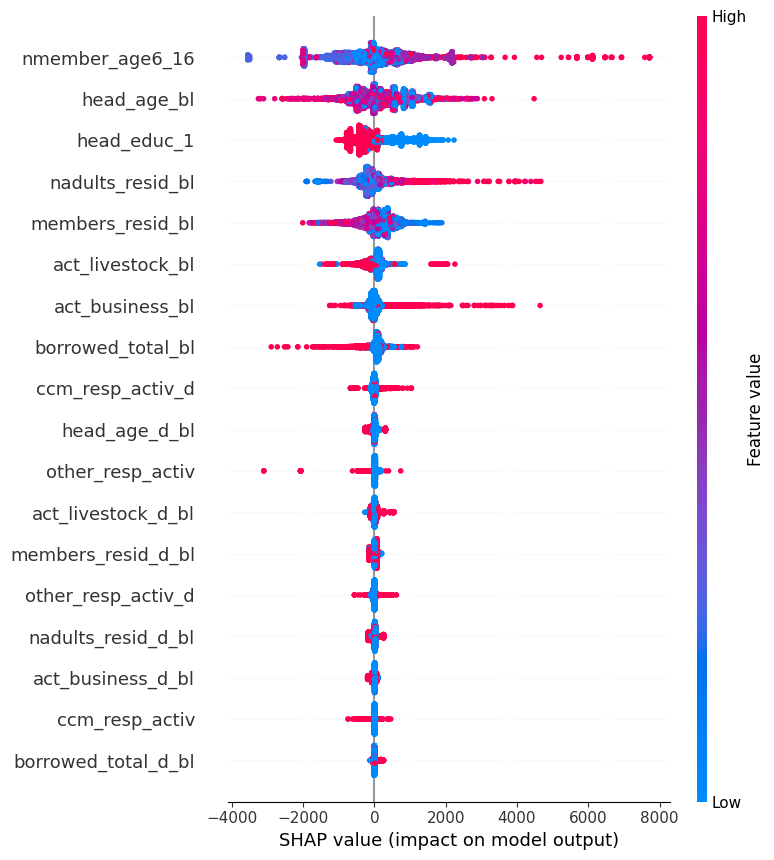

In [18]:
import shap
from econml.dml import CausalForestDML

# fit causal forest with default parameters 
causal_forest = CausalForestDML()
causal_forest.fit(Y, T, X=X, W=W)

# calculate shap values of causal forest model 
shap_values = causal_forest.shap_values(X)
# plot shap values 
# shap.summary_plot(shap_values['Y0']['T0'])
shap.summary_plot(shap_values['loansamt_total']['treatment'])

In [19]:
# use causal forest model to estimate treatment effects  
treatment_effects = causal_forest.effect(X)
# calculate lower bound and upper bound confidence intervals 
lb, ub = causal_forest.effect_interval(X, alpha=0.05)

# convert arrays to pandas dataframes for plotting
te_df = pd.DataFrame(treatment_effects, columns=['cate'])
lb_df = pd.DataFrame(lb, columns=['lb'])
ub_df = pd.DataFrame(ub, columns=['ub'])

# merge dataframes and sort 
df = te_df.merge(lb_df, left_on=te_df.index, right_on=lb_df.index, how='left')
df.drop(columns=['key_0'], inplace=True)
df = df.merge(ub_df, left_on=df.index, right_on=ub_df.index, how='left')
df.drop(columns=['key_0'], inplace=True)
df.sort_values('cate', inplace=True, ascending=True)
df.reset_index(inplace=True, drop=True)

# calculate rolling mean
z = df.rolling(window=30, center=True).mean()

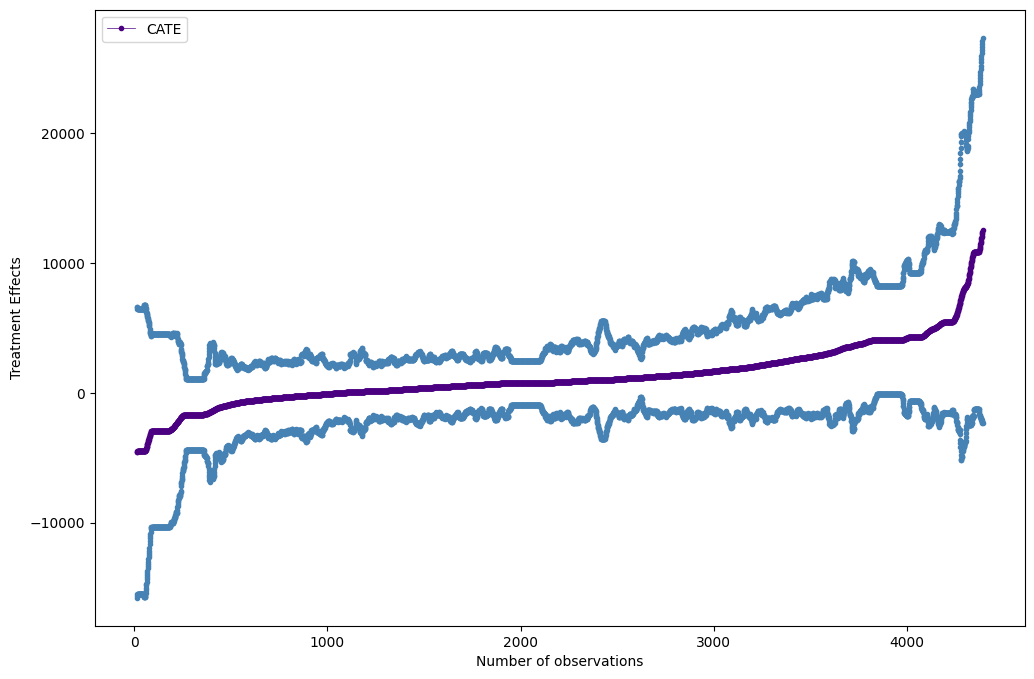

In [20]:
import matplotlib.pyplot as plt

# set plot size
fig, ax = plt.subplots(figsize=(12, 8))
# plot lines for treatment effects and confidence intervals
ax.plot(z['cate'],
        marker='.', linestyle='-', linewidth=0.5, label='CATE', color='indigo')
ax.plot(z['lb'],
        marker='.', linestyle='-', linewidth=0.5, color='steelblue')
ax.plot(z['ub'],
        marker='.', linestyle='-', linewidth=0.5, color='steelblue')
# label axes and create legend
ax.set_ylabel('Treatment Effects')
ax.set_xlabel('Number of observations')
ax.legend()